# Lista 8

## Imports

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.special import digamma
# dla H ( n ) = digamma ( n +1) - digamma (1)

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report


from scipy.stats import pearsonr


## Zadanie 1

In [ ]:
X, y = make_classification(n_samples=1000, n_features=10)

In [65]:
def generate_credit_data(n_samples=1000, n_features=10, random_state=42):
    """Generuje syntetyczne dane kredytowe."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=6,
        n_redundant=2,
        n_clusters_per_class=2,
        random_state=random_state,
    )
    return X, y


def bootstrap_sample(X, y, random_state=None):
    """Losuje próbkę bootstrap (n próbek ze zwracaniem z n). """
    rng = np.random.RandomState(random_state)
    n = len(X)
    indices = rng.choice(n, size=n, replace=True)
    oob_indices = list(set(range(n)) - set(indices))
    return X[indices], y[indices], oob_indices


def train_single_trees(X_train, y_train, n_trees=10):
    """Trenuje n pojedynczych drzew z różnymi seedami."""
    trees = []
    for seed in range(n_trees):
        tree = DecisionTreeClassifier(random_state=seed)
        tree.fit(X_train, y_train)
        trees.append(tree)
    return trees


def calculate_prediction_variance(trees, X):
    """Oblicza wariancję predykcji między drzewami.

    TODO:
    - Zbierz `predict_proba` ze wszystkich drzew
    - Oblicz wariancję dla każdego punktu
    """
    all_probabilities = np.stack([tree.predict_proba(X) for tree in trees])
    return np.var(all_probabilities, axis=0)[:, 0]

def ensemble_predict(trees, X):
    """Agreguje predykcje wielu drzew przez głosowanie większościowe.

    TODO:
    - Zbierz predykcje ze wszystkich drzew
    - Dla każdego punktu zwróć najczęściej występującą klasę
    """
    all_preds = np.stack([tree.predict(X) for tree in trees])
    most_common = np.array([Counter(all_preds[:, i]).most_common(1)[0][0] for i in range(all_preds.shape[1])])
    return most_common


def calculate_oob_error(X, y, trees, oob_indices_list):
    """Oblicza OOB error bez zbioru walidacyjnego.

    `oob_indices_list` musi być listą OOB indeksów równoległą do `trees`.

    TODO:
    - Dla każdego punktu użyj tylko drzew, które go nie widziały
    - Zagłosuj i porównaj z prawdziwą etykietą
    """
    correct = 0
    counted = 0
    for i in range(len(X)):
        oob_trees = [trees[j] for j in range(len(trees)) if i in oob_indices_list[j]]
        if len(oob_trees) == 0:
            continue
        oob_preds = [tree.predict(X[i].reshape(1, -1))[0] for tree in oob_trees]
        vote_pred = Counter(oob_preds).most_common(1)[0][0]
        correct += int(vote_pred == y[i])
        counted += 1
    return 1 - (correct / counted)




### Podpunkt a

In [66]:
X, y = generate_credit_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
trees = train_single_trees(X_train, y_train)

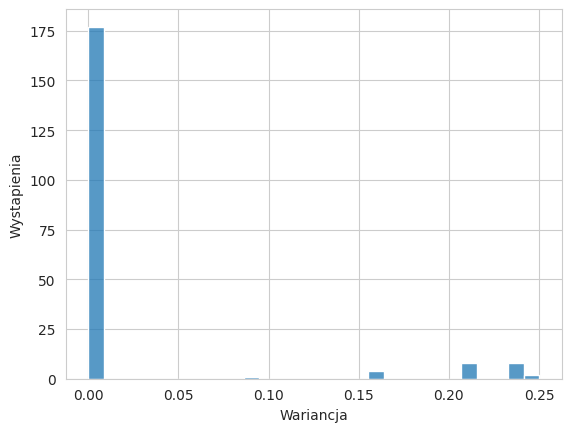

Liczba punktow z wysoka niestabilnoscia: 23
Srednia wariancja:  0.02415


In [67]:
variances = calculate_prediction_variance(trees, X_test)
sns.histplot(variances)
plt.xlabel('Wariancja')
plt.ylabel('Wystapienia')
plt.show()
print('Liczba punktow z wysoka niestabilnoscia:', np.sum(variances > 0.05))
print('Srednia wariancja: ',  variances.mean())

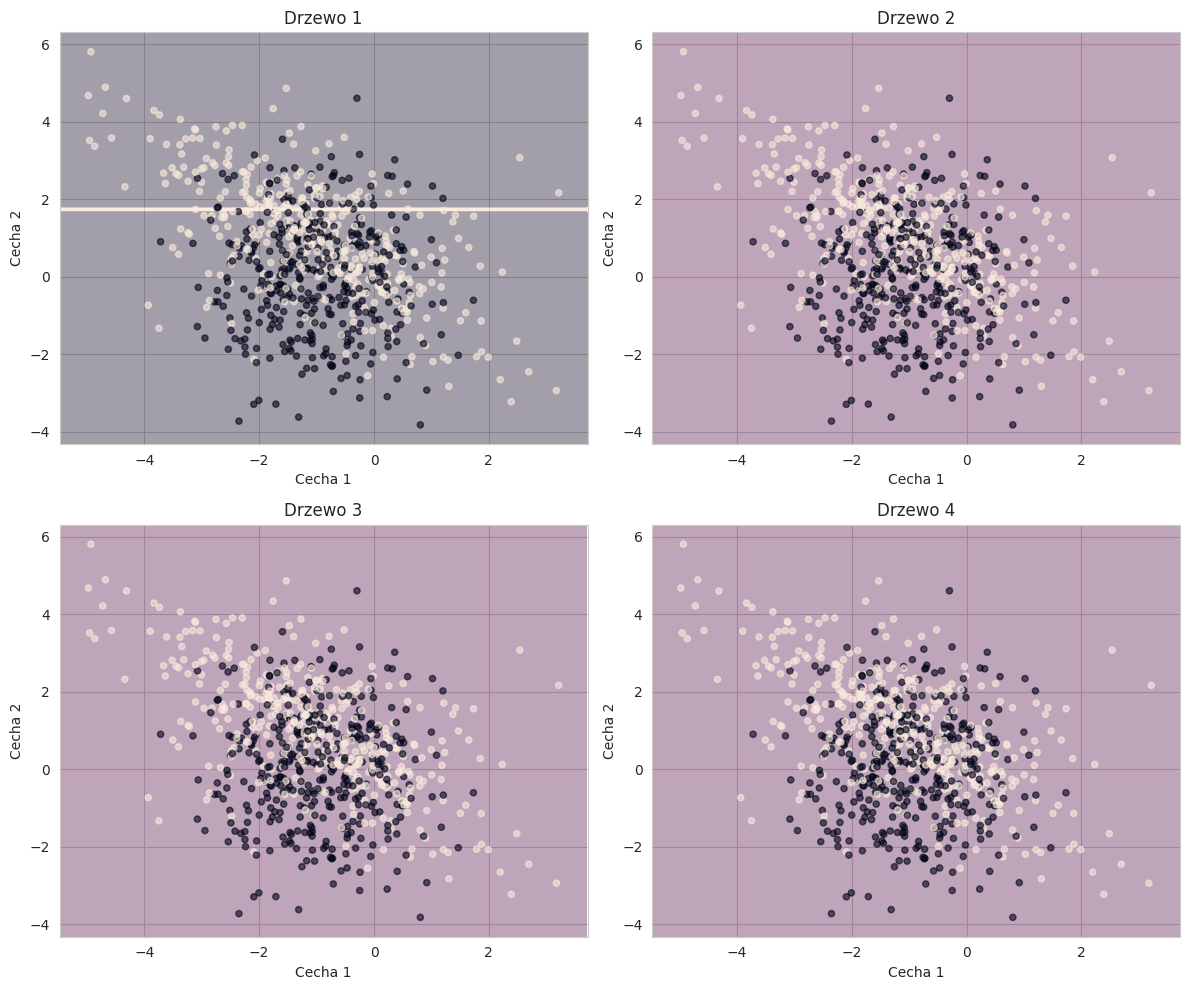

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

means = X_train.mean(axis=0)

for idx, ax in enumerate(axes):
    X_grid = np.tile(means, (xx.ravel().shape[0], 1))
    X_grid[:, 0] = xx.ravel()
    X_grid[:, 1] = yy.ravel()

    Z = trees[idx].predict(X_grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, alpha=0.6)
    ax.set_title(f'Drzewo {idx + 1}')
    ax.set_xlabel('Cecha 1')
    ax.set_ylabel('Cecha 2')

plt.tight_layout()
plt.show()

### Podpunkt b

In [61]:
X, y = generate_credit_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
all_variances = []

for run in range(10):
    trees = []
    for seed in range(50):
        X_sample, y_sample, _ = bootstrap_sample(X_train, y_train)
        tree = DecisionTreeClassifier()
        tree.fit(X_sample, y_sample)
        trees.append(tree)

    variances = calculate_prediction_variance(trees, X_test)
    all_variances.append(variances)

all_variances = np.stack(all_variances)

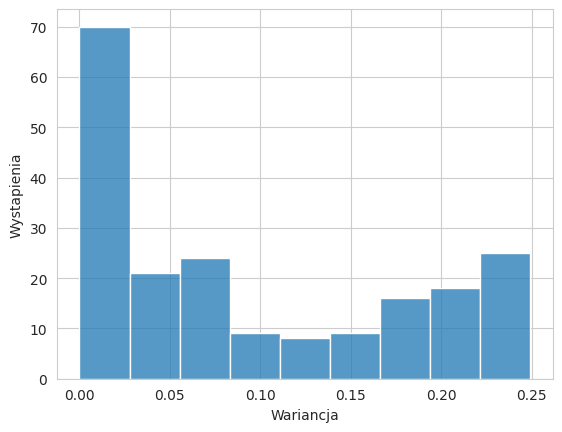

Liczba punktow z wysoka niestabilnoscia: 115
Srednia wariancja: 0.0938


In [63]:
mean_of_variances = np.mean(all_variances, axis=0)
sns.histplot(mean_of_variances)
plt.xlabel('Wariancja')
plt.ylabel('Wystapienia')
plt.show()
print('Liczba punktow z wysoka niestabilnoscia:', np.sum(mean_of_variances > 0.05))
print(f'Srednia wariancja: {mean_of_variances.mean():.4f}')

Jezeli dobrze zrozumialem, to trzeba bylo zrobic srednia wariancji. Mamy 5x wieksza wariancje. Jest tak dlatego, ze korzystamy z bootstrapingu. W tym przypadku wieksza wariancja jest pozadana, poniewaz chcemy miec wieksza roznorodnosc drzew.

### Podpunkt c

In [ ]:
def build_randomized_tree(X_train, y_train, n_trees, max_features=None):
    trees = []
    for seed in range(n_trees):
        X_sample, y_sample, _ = bootstrap_sample(X_train, y_train, random_state=seed)
        tree = DecisionTreeClassifier(max_features=max_features ,random_state=seed)
        tree.fit(X_sample, y_sample)
        trees.append(tree)
    return trees

In [ ]:
def mean_pairwise_correlation(probs):
    n_trees = probs.shape[0]
    correlations = []
    for i in range(n_trees):
        for j in range(i+1, n_trees):
            corr, _ = pearsonr(probs[i], probs[j])
            correlations.append(corr)
    return np.mean(correlations)

In [ ]:
trees_all = build_randomized_tree(X_train, y_train, n_trees=50, max_features=None)
trees_sqrt = build_randomized_tree(X_train, y_train, n_trees=50, max_features='sqrt')

probs_all = np.stack([t.predict_proba(X_test)[:, 1] for t in trees_all])
probs_sqrt = np.stack([t.predict_proba(X_test)[:, 1] for t in trees_sqrt])

print(f'Korelacja (wszystkie cechy): {mean_pairwise_correlation(probs_all):.4f}')
print(f'Korelacja (sqrt cechy):      {mean_pairwise_correlation(probs_sqrt):.4f}')

In [ ]:
variances_all = calculate_prediction_variance(trees_all, X_test)
variances_sqrt = calculate_prediction_variance(trees_sqrt, X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].hist(variances_all)
axes[0].set_title('Bez losowania cech')
axes[1].hist(variances_sqrt)
axes[1].set_title('Z losowaniem cech')
fig.supylabel("Wystapienia")
fig.supxlabel("Wariancja")
plt.show()

print(f"Srednia wariancja wszystkich {variances_all.mean():.4f}")
print(f"Srednia wariancja losowania {variances_sqrt.mean():.4f}")

Drzewa z losowaniem sa bardziej roznorodne.

### Podpunkt d

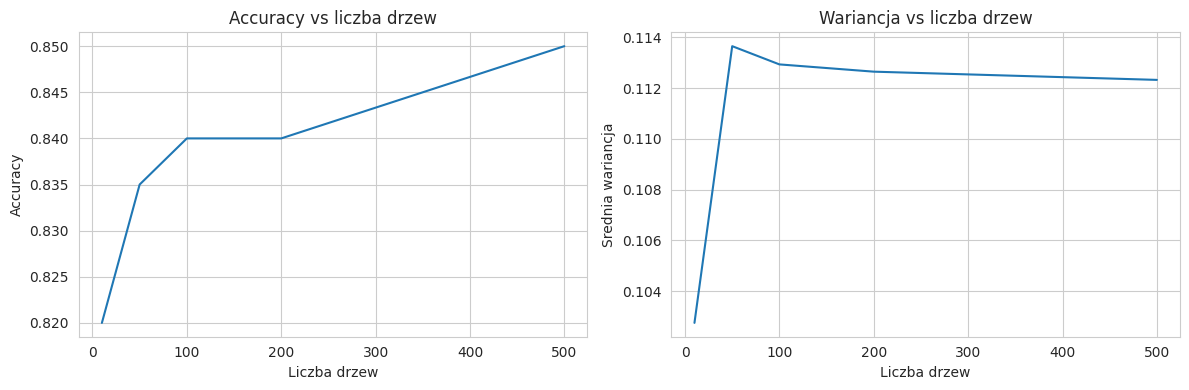

n_trees= 10: acc=0.8200, var=0.1028
n_trees= 50: acc=0.8350, var=0.1136
n_trees=100: acc=0.8400, var=0.1129
n_trees=200: acc=0.8400, var=0.1126
n_trees=500: acc=0.8500, var=0.1123


In [54]:
n_trees_list = [10, 50, 100, 200, 500]
accuracies = []
variances_mean = []

for n_trees in n_trees_list:
    trees = build_randomized_tree(X_train, y_train, n_trees=n_trees, max_features='sqrt')

    preds = ensemble_predict(trees, X_test)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)

    var = calculate_prediction_variance(trees, X_test).mean()
    variances_mean.append(var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_trees_list, accuracies)
axes[0].set_xlabel('Liczba drzew')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs liczba drzew')

axes[1].plot(n_trees_list, variances_mean)
axes[1].set_xlabel('Liczba drzew')
axes[1].set_ylabel('Srednia wariancja')
axes[1].set_title('Wariancja vs liczba drzew')

plt.tight_layout()
plt.show()

for n, acc, var in zip(n_trees_list, accuracies, variances_mean):
    print(f"n_trees={n:3d}: acc={acc:.4f}, var={var:.4f}")

Nasycenie nastepuje przy n == 100

In [ ]:
def build_trees_with_oob(X_train, y_train, n_trees=50, max_features='sqrt'):
    trees = []
    oob_indices_list = []

    for seed in range(n_trees):
        X_sample, y_sample, oob_indices = bootstrap_sample(X_train, y_train, random_state=seed)
        tree = DecisionTreeClassifier(max_features=max_features, random_state=seed)
        tree.fit(X_sample, y_sample)
        trees.append(tree)
        oob_indices_list.append(oob_indices)

    return trees, oob_indices_list

In [69]:
trees, oob_indices_list = build_trees_with_oob(X_train, y_train, n_trees=100)
oob_error = calculate_oob_error(X_train, y_train, trees, oob_indices_list)
print(f"OOB Error: {oob_error:.4f}")
print(f"OOB Accuracy: {1 - oob_error:.4f}")


preds = ensemble_predict(trees, X_test)
test_acc = np.mean(preds == y_test)
print(f"Test Accuracy: {test_acc:.4f}")

OOB Error: 0.0850
OOB Accuracy: 0.9150
Test Accuracy: 0.8400


In [73]:
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', oob_score=True, random_state=42)
rf.fit(X_train, y_train)
print(f"OOB Accuracy: {rf.oob_score_:.4f}")
print(f"Test Accuracy: {rf.score(X_test, y_test):.4f}")

OOB Accuracy: 0.9113
Test Accuracy: 0.8550


Sa prawie identyczne

Nie umiem samemu. Po konwersacji z chatbotem dotarlem do wzoru: Wariancja lasu = (blad jednego drzewa / liczba drzew) + podobienstwo drzew.

Random forest zwieksza liczbe drzew oraz zmiejsza ich podobienstwo przez losowanie cech.

## Zadanie 2

In [8]:
def generate_network_data(n_normal=950, n_anomaly=50, random_state=42):
    """ Generuje dane ruchu sieciowego z anomaliami . """
    np.random.seed(random_state)

    # Normalny ruch - 3 klastry operacyjne
    normal = np.vstack([
        np.random.randn(n_normal // 3, 4) * 0.5 + [50, 100, 0.8, 30],
        np.random.randn(n_normal // 3, 4) * 0.5 + [55, 110, 0.75, 35],
        np.random.randn(n_normal // 3, 4) * 0.5 + [48, 95, 0.85, 28],
    ])

    # Anomalie - rozne wzorce atakow
    anomalies = np.vstack([
        np.random.randn(n_anomaly // 2, 4) * 0.3 + [200, 500, 0.1, 5],
        # DDoS
        np.random.randn(n_anomaly // 2, 4) * 0.3 + [10, 10, 0.99, 100], # Port scan
    ])

    X = np.vstack([normal, anomalies])
    y = np.array([0] * len(normal) + [1] * len(anomalies))
    return X, y

class IsolationTree:
    """ Pojedyncze drzewo izolujace . """
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, current_depth=0):
        """ Buduje drzewo z losowymi podzialami ( bez etykiet !) . """
        n_samples, n_features = X.shape

        # Warunek stopu
        if n_samples <= 1 or (self.max_depth and current_depth >= self.max_depth):
            return {'type': 'leaf', 'size': n_samples, 'depth': current_depth}

        # TODO : Losuj ceche i prog
        feature = np.random.randint(0, n_features)
        min_val, max_val = X[:, feature].min(), X[:, feature].max()
        threshold = np.random.uniform(min_val, max_val)

        # TODO : Podziel dane i rekurencyjnie buduj poddrzewa
        left = X[X[:, feature] < threshold]
        right = X[X[:, feature] >= threshold]

        node =  {
            'type': 'node',
            'left': self.fit(left, current_depth+1),
            'right': self.fit(right, current_depth+1),
            'threshold': threshold,
            'feature': feature,
            'size': n_samples,
            'depth': current_depth
        }

        if current_depth == 0:
            self.root = node

        return node

    def path_length(self, x, node=None, current_depth=0):
        """ Oblicza glebokosc izolacji punktu x . """
        # TODO : Rekurencyjnie przejdz drzewo az do liscia
        if current_depth == 0:
            node = self.root

        if node['type'] == "leaf" or (self.max_depth and current_depth >= self.max_depth):
            return current_depth

        if x[node['feature']] < node['threshold']:
            return self.path_length(x, node=node['left'], current_depth=current_depth+1)
        else:
            return self.path_length(x, node=node['right'], current_depth=current_depth+1)


def c_factor(n):
    """ Oblicza oczekiwana glebokosc BST dla n elementow . """
    if n <= 1:
        return 0
    return 2 * (np.log(n - 1) + 0.5772156649) - 2 * (n - 1) / n

def anomaly_score(path_lengths, n_samples):
    """ Oblicza znormalizowany anomaly score . """
    c = c_factor(n_samples)
    return 2 ** (-np.array(path_lengths) / c)

In [9]:
X, y = generate_network_data()

### Podpunkt a

In [10]:
isolationTree = IsolationTree()

In [11]:
isolationTree.fit(X)

{'type': 'node',
 'left': {'type': 'node',
  'left': {'type': 'node',
   'left': {'type': 'node',
    'left': {'type': 'node',
     'left': {'type': 'leaf', 'size': 1, 'depth': 5},
     'right': {'type': 'leaf', 'size': 1, 'depth': 5},
     'threshold': 10.084731921663336,
     'feature': 1,
     'size': 2,
     'depth': 4},
    'right': {'type': 'node',
     'left': {'type': 'node',
      'left': {'type': 'leaf', 'size': 1, 'depth': 6},
      'right': {'type': 'leaf', 'size': 1, 'depth': 6},
      'threshold': 99.62566396317024,
      'feature': 3,
      'size': 2,
      'depth': 5},
     'right': {'type': 'node',
      'left': {'type': 'leaf', 'size': 1, 'depth': 6},
      'right': {'type': 'node',
       'left': {'type': 'leaf', 'size': 1, 'depth': 7},
       'right': {'type': 'leaf', 'size': 1, 'depth': 7},
       'threshold': 10.586537228871908,
       'feature': 0,
       'size': 2,
       'depth': 6},
      'threshold': 9.909198639667801,
      'feature': 1,
      'size': 3,
   

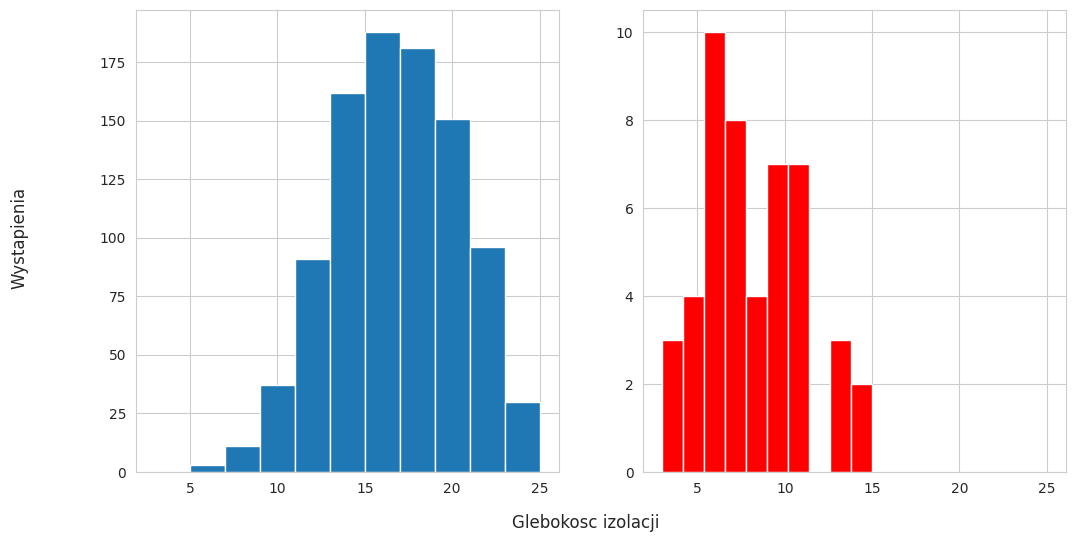

In [23]:
isolationDepth = [isolationTree.path_length(x) for x in X]

normalDepth = isolationDepth[:950]
anomaliesDepth = isolationDepth[950:]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

axes[0].hist(normalDepth)
axes[1].hist(anomaliesDepth, color='red')
fig.supylabel('Wystapienia')
fig.supxlabel('Glebokosc izolacji')
plt.show()

Na wykresie widzimy, ze anomalie maja mniejsza odleglosc do liscia, dzieki czemu latwiej je odizolowac.

### Podpunkt b

In [50]:
def generate2DData(n_normal=950, n_anomaly=50, random_state=42):
    np.random.seed(random_state)

    normalPoints = np.random.normal(0, 10, size=(n_normal, 2))

    angles = np.random.uniform(0, 2 * np.pi, n_anomaly)
    radius = np.random.uniform(30, 35, n_anomaly)
    anomalies = np.column_stack([radius * np.cos(angles), radius * np.sin(angles)])

    X = np.vstack([normalPoints, anomalies])
    y = np.array([0] * n_normal + [1] * n_anomaly)

    return X, y

In [51]:
X, y = generate2DData()

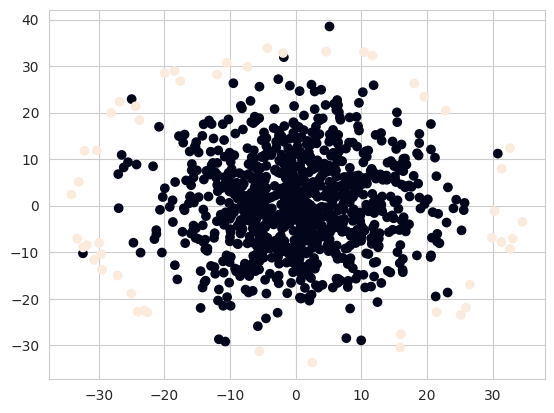

In [54]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [55]:
isolationTree = IsolationTree()
isolationTree.fit(X)

{'type': 'node',
 'left': {'type': 'node',
  'left': {'type': 'leaf', 'size': 1, 'depth': 2},
  'right': {'type': 'node',
   'left': {'type': 'node',
    'left': {'type': 'node',
     'left': {'type': 'leaf', 'size': 1, 'depth': 5},
     'right': {'type': 'node',
      'left': {'type': 'node',
       'left': {'type': 'node',
        'left': {'type': 'node',
         'left': {'type': 'node',
          'left': {'type': 'leaf', 'size': 1, 'depth': 10},
          'right': {'type': 'leaf', 'size': 1, 'depth': 10},
          'threshold': -9.409272828569192,
          'feature': 1,
          'size': 2,
          'depth': 9},
         'right': {'type': 'leaf', 'size': 1, 'depth': 9},
         'threshold': -8.585939827661514,
         'feature': 1,
         'size': 3,
         'depth': 8},
        'right': {'type': 'node',
         'left': {'type': 'node',
          'left': {'type': 'leaf', 'size': 1, 'depth': 10},
          'right': {'type': 'node',
           'left': {'type': 'leaf', 'size': 

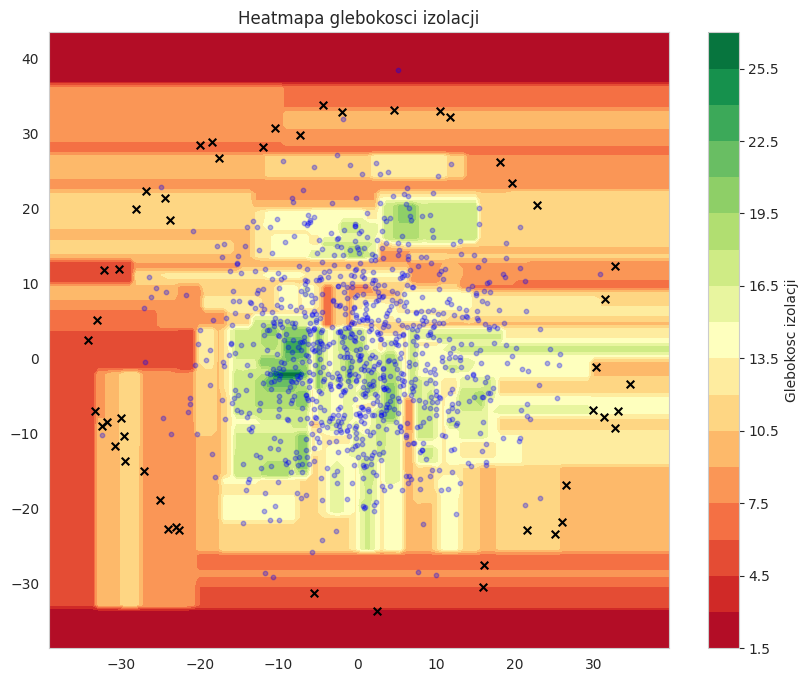

In [65]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-5, X[:, 0].max()+5, 100),
                             np.linspace(X[:, 1].min()-5, X[:, 1].max()+5, 100))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

depths = np.array([isolationTree.path_length(p) for p in grid_points]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, depths, levels=20, cmap='RdYlGn')
plt.colorbar(label='Glebokosc izolacji')
plt.scatter(X[:950, 0], X[:950, 1], c='blue', alpha=0.3, s=10)
plt.scatter(X[950:, 0], X[950:, 1], c='black', s=30, marker='x')
plt.title('Heatmapa glebokosci izolacji')
plt.show()

Na heatmapie widac, ze anomalie sa odcinane o wiele wczesniej.

Wyjaśnij: “rzadkie punkty = mało sąsiadów = szybka izolacja”

Losowe podzialy dziela przestrzen na dwie czesci. O wiele szybciej beda oddzielane punkty odstajace (rzadkie i malo sasiadow), bo wystarczy mniej podzialow.

### Podpunkt c

In [67]:
trees = []
for i in range(100):
    indices = np.random.choice(len(X), size=256, replace=False)
    isolationTree = IsolationTree()
    isolationTree.fit(X[indices])
    trees.append(isolationTree)

In [69]:
avgDepthPoints = [np.mean([tree.path_length(x) for tree in trees]) for x in X]

In [70]:
anomalyScore = anomaly_score(avgDepthPoints, len(X))

threshold = np.percentile(anomalyScore, 95)
preds = (anomalyScore >= threshold).astype(int)

### Podpunkt dm

In [74]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X)
lof_preds = (lof_preds == -1).astype(int)  # -1 = anomalia

In [76]:
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
ocsvm_preds = ocsvm.fit_predict(X)
ocsvm_preds = (ocsvm_preds == -1).astype(int)

In [79]:
print("\n Moj isolation forest\n")
print(classification_report(y, preds))
print("\nLocal Outlier Factor\n")
print(classification_report(y, lof_preds))
print("One class SVM")
print(classification_report(y, ocsvm_preds))


 Moj isolation forest

              precision    recall  f1-score   support

           0       0.94      0.61      0.74       950
           1       0.03      0.24      0.06        50

    accuracy                           0.59      1000
   macro avg       0.49      0.43      0.40      1000
weighted avg       0.89      0.59      0.71      1000


Local Outlier Factor

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       950
           1       0.62      0.62      0.62        50

    accuracy                           0.96      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.96      0.96      0.96      1000

One class SVM
              precision    recall  f1-score   support

           0       0.94      0.61      0.74       950
           1       0.03      0.24      0.06        50

    accuracy                           0.59      1000
   macro avg       0.49      0.43      0.40      1000
weighted avg 

In [81]:
for tree_count in [50, 100, 200]:
    for size in [64, 128, 256]:
        trees = []
        for i in range(tree_count):
            indices = np.random.choice(len(X), size=size, replace=False)
            isolationTree = IsolationTree()
            isolationTree.fit(X[indices])
            trees.append(isolationTree)
        avgDepthPoints = [np.mean([tree.path_length(x) for tree in trees]) for x in X]
        anomalyScore = anomaly_score(avgDepthPoints, len(X))

        threshold = np.percentile(anomalyScore, 95)
        preds = (anomalyScore >= threshold).astype(int)
        print(f"\nTree count: {tree_count}\nSize: {size}\n")
        print(classification_report(y, preds))


Tree count: 50
Size: 64

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.76      0.76      0.76        50

    accuracy                           0.98      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.98      0.98      0.98      1000


Tree count: 50
Size: 128

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.82      0.82      0.82        50

    accuracy                           0.98      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.98      0.98      0.98      1000


Tree count: 50
Size: 256

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.83      0.86      0.84        50

    accuracy                           0.98      1000
   macro avg       0.91      0.93      0.92     

Najlepsza konfiguracja to 200 drzew i 64 rozmiar probki. Wiekszy rozmiar drzew nieznacznie poprawia wyniki. Mniejsza probka nieznacznie poprawia wyniki. Mniejsza probka == wieksza roznorodnosc drzew.

In [85]:
skIsolationForest = IsolationForest(n_estimators=200, max_samples=64)
skPreds = skIsolationForest.fit_predict(X)

print(f"\nTree count: 200\nSize: 64\n")
print(classification_report(y, preds))


Tree count: 200
Size: 64

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       950
           1       0.82      0.84      0.83        50

    accuracy                           0.98      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.98      0.98      0.98      1000



Wyniki sa porownywalnem